# Conversão de `main.py` para Jupyter Notebook

Este notebook é uma cópia de `main.py`, organizada em **células separadas** para permitir que cada trecho de código seja executado isoladamente.


## 1) Imports e configurações iniciais

Importe as dependências necessárias (equivalente ao topo de `main.py`).


In [2]:
from utils import encontrar_pdfs, regra_divisao, extrair_tabela_por_linhas_vermelhas
from leitor_pdf import dividir_pdf
import pdfplumber, json
import importlib
import utils
importlib.reload(utils)

print("Imports carregados")


Imports carregados


## 2) Listar PDFs e iterar sobre eles

Este bloco corresponde ao loop principal de `main.py` que percorre os arquivos na pasta `arquivos/pastateste`.


In [3]:
pdf_folder = "arquivos/pastateste"

pdfs_encontrados = [f for f in encontrar_pdfs(pdf_folder) if f.lower().endswith(".pdf")]
print(f"Encontrados {len(pdfs_encontrados)} PDFs em {pdf_folder}")
for arquivo in pdfs_encontrados:
    print("-", arquivo)


Encontrados 1 PDFs em arquivos/pastateste
- arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf


## 3) Processar cada PDF (célula principal)

O bloco a seguir corresponde ao corpo do `for` em `main.py`. Ele abre cada PDF, define classes auxiliares e realiza a extração.


In [4]:
# Escolha um PDF para analisar (altere o índice conforme necessário)
idx = 0
arquivo = pdfs_encontrados[idx]
print(f"Analisando: {arquivo}")


Analisando: arquivos/pastateste/Tormenta20-Edicao-Jogo-do-Ano-v1.3.pdf


In [4]:
# Definições de classes para metadados de texto (originais em `main.py`)

class Topico:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Titulo:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Subtitulo:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


class Tabela:
    def __init__(self, texto, tamanho_fonte=None, cor_fonte=None):
        self.texto = texto
        self.tamanho_fonte = tamanho_fonte
        self.cor_fonte = cor_fonte if cor_fonte is None else cor_fonte

        # Garantir que as cores sejam arrays de 3 posições [R, G, B]
        if self.cor_fonte is not None and not isinstance(self.cor_fonte, list):
            self.cor_fonte = [0, 0, 0]


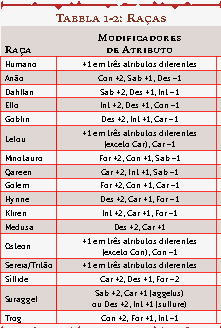

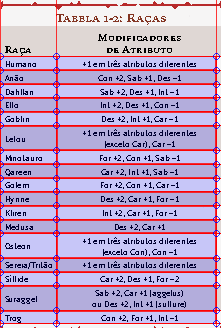

[['Humano', '+1 em três atributos diferentes'], ['Anão', 'Con +2, Sab +1, Des –1'], ['Dahllan', 'Sab +2, Des +1, Int –1'], ['Elfo', 'Int +2, Des +1, Con –1'], ['Goblin', 'Des +2, Int +1, Car –1'], ['Lefou', '+1 em três atributos diferentes\n(exceto Car), Car –1'], ['Minotauro', 'For +2, Con +1, Sab –1'], ['Qareen', 'Car +2, Int +1, Sab –1'], ['Golem', 'For +2, Con +1, Car –1'], ['Hynne', 'Des +2, Car +1, For –1'], ['Kliren', 'Int +2, Car +1, For –1'], ['Medusa', 'Des +2, Car +1'], ['Osteon', '+1 em três atributos diferentes\n(exceto Con), Con –1'], ['Sereia/Tritão', '+1 em três atributos diferentes'], ['Sílfide', 'Car +2, Des +1, For –2'], ['Suraggel', 'Sab +2, Car +1 (aggelus)\nou Des +2, Int +1 (sulfure)'], ['Trog', 'Con +2, For +1, Int –1']]


In [136]:
# Seleção de página e recorte das colunas

# Ajuste esse
#  índice para a página desejada (0-index)
pagina_idx = 23

from IPython.display import display

with pdfplumber.open(arquivo) as pdf:
    page = pdf.pages[pagina_idx]

    cropped = extrair_tabela_por_linhas_vermelhas(page)

    # if cropped is not None:
    #     display(cropped.to_image(resolution=150))
    # else:
    #     print("Não foi possível encontrar a área da tabela na página.")
    
    lines = [
            ((cropped.rects[0]['x0'], cropped.rects[0]['bottom']),(cropped.rects[-2]['x0'], cropped.bbox[-1]-5)), # Linha esquerda
            ((cropped.rect_edges[12]['x0'], cropped.rects[0]['bottom']),(cropped.rect_edges[12]['x0'], cropped.bbox[-1]-5)), # Linha central divisória
            ((cropped.rects[-2]['x0'], cropped.bbox[-1]-5), (cropped.rects[-1]['x1'], cropped.bbox[-1]-5)), # Linha inferior
            ((cropped.rects[-1]['x1']-5, cropped.bbox[-1]-5),(cropped.rects[1]['x1']-5, cropped.rects[1]['bottom'])), # Linha direita
            ((cropped.rects[1]['x1'], cropped.rects[1]['bottom']),(cropped.rects[0]['x0'], cropped.rects[0]['bottom'])) # Linha superior
        ]

    destac_rects = cropped.to_image().draw_lines(lines)
    destac_rects = destac_rects.draw_lines(cropped.rects[2:])
    display(destac_rects)

    # 1. Extraia os valores de X únicos das suas linhas verticais
    # Baseado no seu código, os limites de colunas estão nestes pontos:
    v_coords = sorted(list(set([
        lines[0][0][0],  # X da Linha esquerda
        lines[1][0][0],  # X da Linha central divisória
        lines[3][0][0]   # X da Linha direita
    ])))

    # 2. Extraia os valores de Y para as linhas horizontais
    # Coletamos o topo e a base de cada retângulo para criar as divisórias de linha
    h_coords = sorted(list(set(
        [lines[4][0][1], lines[2][0][1]] + # Linha superior e inferior do desenho
        [r["top"] for r in cropped.rects[2:]] + # Topo de cada linha de dado
        [r["bottom"] for r in cropped.rects[2:]] # Base de cada linha de dado
    )))

    # 3. Configure a extração explícita
    table_settings = {
        "vertical_strategy": "explicit",
        "explicit_vertical_lines": v_coords,
        
        # Agora usamos estratégia explícita também para o horizontal
        "horizontal_strategy": "explicit", 
        "explicit_horizontal_lines": h_coords,
        
        "snap_y_tolerance": 6,
        "join_tolerance": 5,
    }

    # 4. Extraia a tabela
    table = cropped.extract_table(table_settings=table_settings)

    display(destac_rects.debug_tablefinder(table_settings=table_settings))
    print(table)

    # table_settings = {
    #     "vertical_strategy": "explicit",       # IGNORA o texto, usa as linhas abaixo
    #     "horizontal_strategy": "explicit",     # IGNORA o texto, usa as linhas abaixo
    #     "explicit_vertical_lines": v_lines,    # Suas colunas exatas
    #     "explicit_horizontal_lines": h_lines,  # Suas linhas exatas
    #     "snap_y_tolerance": 5,
    #     "join_tolerance": 5
    # }
    # display(destac_rects.debug_tablefinder(table_settings=table_settings))

# for linha in cropped.extract_text_lines():
#     print(linha['text'])


In [ ]:
# Iterar sobre as linhas extraídas e detectar padrões
largura = page.width
altura = page.height-32 # cortar rodapé

coluna_esquerda = page.crop((0, 0, largura/2, altura))
coluna_direita = page.crop((largura/2, 0, largura, altura))

pagina_completa = coluna_esquerda.extract_text_lines() + coluna_direita.extract_text_lines()

for linha in pagina_completa:
    R, G, B = (
        linha["chars"][0]["non_stroking_color"][0],
        linha["chars"][0]["non_stroking_color"][1],
        linha["chars"][0]["non_stroking_color"][2],
    )
    tam_fonte = linha["chars"][0]["size"]

    params_title = all(pixel_color * 255 > 200 for pixel_color in (R, G, B)) and tam_fonte >= 15

    if "Tabela" in linha["text"]:
        list_tabela = Tabela(linha["text"], tam_fonte, [R, G, B])
        print(linha["chars"][0])

    # if (params_title):
    #     print(linha['text'])
    #     print(tam_fonte)


{'matrix': (12.0, 0.0, 0.0, 12.0, 344.724, 380.4483), 'fontname': 'ITPJJY+IowanOldStyle-Bold', 'adv': 0.6890000000000001, 'upright': True, 'x0': 344.724, 'y0': 374.97630000000004, 'x1': 352.99199999999996, 'y1': 386.97630000000004, 'width': 8.267999999999972, 'height': 12.0, 'size': 12.0, 'mcid': None, 'tag': None, 'object_type': 'char', 'page_number': 24, 'ncs': 'ICCBased', 'text': 'T', 'stroking_color': (0,), 'non_stroking_color': (0.513, 0.202, 0.129), 'top': 392.5517, 'bottom': 404.5517, 'doctop': 18321.6957}
